# SARSA

## Configurando a visualização em vídeo
Para gerar um vídeo de repetição do agente e do ambiente.


In [ ]:
%%capture
!pip install pyglet==1.5.1
!apt install python-opengl
!apt install ffmpeg
!apt install xvfb
!pip3 install pyvirtualdisplay

# Virtual display
from pyvirtualdisplay import Display

virtual_display = Display(visible=0, size=(1400, 900))
virtual_display.start()

## Instalando  dependências

In [ ]:
%%capture
!pip install pygame
!pip install imageio imageio_ffmpeg

## Import the packages

In [ ]:
import numpy as np
import gymnasium as gym
import random
import imageio
from tqdm.notebook import trange

## Frozen Lake

In [ ]:
# Create the FrozenLake-v1 environment using 4x4 map and non-slippery version
env = gym.make("FrozenLake-v1",map_name="4x4",is_slippery=False, render_mode="rgb_array")

array([[[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]],

       [[180, 200, 230],
        [204, 230, 255],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       ...,

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [235, 245, 249],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]]], dtype=uint8)
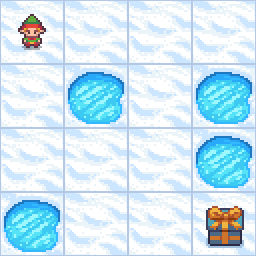

In [ ]:
env.reset()
env.render()

### Understanding the FrozenLake environment

In [ ]:
print("_____ESPAÇO DE OBSERVAÇÃO_____ \n")
print("Espaço de Observação", env.observation_space)
print("Amostra de uma observação", env.observation_space.sample()) # Pegar uma observação aleatória

_____ESPAÇO DE OBSERVAÇÃO_____ 

Espaço de Observação Discrete(16)
Amostra de uma observação 3


In [ ]:
print("\n _____ESPAÇO DE AÇÃO_____ \n")
print("Espaço de ação", env.action_space.n)
print("Amostra de espaço de ação", env.action_space.sample()) # Tomar uma ação aleatória


 _____ESPAÇO DE AÇÃO_____ 

Espaço de ação 4
Amostra de espaço de ação 2


## Criando e inicializando uma Q-Table

In [ ]:
state_space = env.observation_space.n
print("Existem ", state_space, " estados possíveis")

action_space = env.action_space.n
print("Existem ", action_space, " estados possíveis")

Existem  16  estados possíveis
Existem  4  estados possíveis


In [ ]:
# Let's create our Qtable of size (state_space, action_space) and initialized each values at 0 using np.zeros
def initialize_q_table(state_space, action_space):
    Qtable = np.zeros((state_space, action_space))
    return Qtable

In [ ]:
Qtable_frozenlake = initialize_q_table(state_space, action_space)

In [ ]:
Qtable_frozenlake

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [ ]:
Qtable_frozenlake.shape

(16, 4)

## Definindo a política epsilon-greedy


In [ ]:
def epsilon_greedy_policy(Qtable, state, epsilon):
    # Gere aleatoriamente um número entre 0 e 1
    random_int = random.uniform(0,1)
    # Se random é maior que epsilon --> exploitation (fazer uma ação baseada na experiência)
    if random_int > epsilon:
        # Execute a ação com o valor mais alto dado um estado
        # np.argmax can be useful here
        action = np.argmax(Qtable[state])
      # else --> exploration (fazer uma ação aleatória para avaliar novos ações)
    else:
       action = env.action_space.sample()

    return action

## Definindo a política greedy

In [ ]:
def greedy_policy(Qtable, state):
    # Exploitation: take the action with the highest state, action value
    action = np.argmax(Qtable[state])

    return action

## Configurar os hiperparâmetros

In [ ]:
# Parâmetros de treinamento
n_training_episodes = 10000  # Total de episódios de treinamento
learning_rate = 0.7          # Taxa de aprendizagem

# Parâmetros de avaliação
n_eval_episodes = 100        # Número total de episódios de teste

# Parâmetros do Environment
env_id = "FrozenLake-v1"     # Nome do environment
max_steps = 20               # Máximo de passos por episódio
gamma = 0.95                 # Taxa de desconto
eval_seed = []               # A semente de avaliação do meio ambiente

# Parâmetros de exploração
max_epsilon = 1.0             # Probabilidade de exploração no início
min_epsilon = 0.05            # Probabilidade mínima de exploração
decay_rate = 0.0005           # Taxa de decaimento exponencial para problema de exploração

## Treinando o modelo

In [ ]:
def sarsa_train(n_training_episodes, min_epsilon, max_epsilon, decay_rate, env, max_steps, Qtable):
    for episode in trange(n_training_episodes):
        epsilon = min_epsilon + (max_epsilon - min_epsilon)*np.exp(-decay_rate*episode)
        state, info = env.reset()
        action = epsilon_greedy_policy(Qtable, state, epsilon)  # Escolhe primeira ação

        for step in range(max_steps):
            new_state, reward, done, truncated, info = env.step(action)

            # SARSA: escolhe a próxima ação ANTES de atualizar
            new_action = epsilon_greedy_policy(Qtable, new_state, epsilon)

            # Atualização SARSA (usa a_next escolhida, não max)
            Qtable[state][action] = Qtable[state][action] + learning_rate * (
                reward + gamma * Qtable[new_state][new_action] - Qtable[state][action]
            )

            if done or truncated:
                break

            state = new_state
            action = new_action  # Usa a ação já escolhida

    return Qtable

In [ ]:
Qtable_frozenlake = sarsa_train(n_training_episodes, min_epsilon, max_epsilon, decay_rate, env, max_steps, Qtable_frozenlake)

  0%|          | 0/10000 [00:00<?, ?it/s]

## Tabela do SARSA treinada

In [ ]:
Qtable_frozenlake

array([[0.4243047 , 0.19134603, 0.59339971, 0.19511559],
       [0.10477397, 0.        , 0.77681756, 0.3412211 ],
       [0.30826738, 0.85661893, 0.63869495, 0.68484248],
       [0.78954852, 0.        , 0.06304325, 0.02300706],
       [0.19063372, 0.08531828, 0.        , 0.19089676],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.9023867 , 0.        , 0.49542207],
       [0.        , 0.        , 0.        , 0.        ],
       [0.0853599 , 0.        , 0.22533223, 0.27678331],
       [0.35832008, 0.88815497, 0.60567974, 0.        ],
       [0.81543992, 0.94999271, 0.        , 0.73729309],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.74592926, 0.94955579, 0.75268012],
       [0.89211728, 0.95      , 1.        , 0.7829441 ],
       [0.        , 0.        , 0.        , 0.        ]])

## Avaliando o modelo

In [ ]:
def evaluate_agent(env, max_steps, n_eval_episodes, Q, seed):
    """
    Evaluate the agent for ``n_eval_episodes`` episodes and returns average reward and std of reward.
    :param env: The evaluation environment
    :param n_eval_episodes: Number of episode to evaluate the agent
    :param Q: The Q-table
    :param seed: The evaluation seed array (for taxi-v3)
    """
    episode_rewards = []
    for episode in range(n_eval_episodes):
        if seed:
            state, _ = env.reset(seed=seed[episode]) # Fixed: extract observation
        else:
            state, _ = env.reset() # Fixed: extract observation
        step = 0
        done = False
        total_rewards_ep = 0

        for step in range(max_steps):
            # Tome a ação (índice) que tem a recompensa futura máxima esperada dado esse estado
            action = np.argmax(Q[state][:]) # Não preciso explorar (aleatoriamente)
            new_state, reward, done, truncated, info = env.step(action) # Fixed: include truncated
            total_rewards_ep += reward

            if done or truncated:
                break
            state = new_state
        episode_rewards.append(total_rewards_ep)
    mean_reward = np.mean(episode_rewards)
    std_reward = np.std(episode_rewards)

    return mean_reward, std_reward

In [ ]:
# Evaluate our Agent
mean_reward, std_reward = evaluate_agent(env, max_steps, n_eval_episodes, Qtable_frozenlake, eval_seed)
print(f"Mean_reward={mean_reward:.2f} +/- {std_reward:.2f}")

Mean_reward=1.00 +/- 0.00


## Visualizando os resultados

In [ ]:
def record_video(env, Qtable, out_directory, fps=1):
    images = []
    done = False
    state, _ = env.reset(seed=random.randint(0,500)) # Fixed: extract observation
    img = env.render()
    images.append(img)
    while not done:
        # Take the action (index) that have the maximum expected future reward given that state
        action = greedy_policy(Qtable, state)
        state, reward, done, truncated, info = env.step(action) # Fixed: include truncated
        img = env.render()
        images.append(img)
    imageio.mimsave(out_directory, [np.array(img) for i, img in enumerate(images)], fps=fps)

Salvando arquivo animado como GIF com 1 quadro por segundo

In [ ]:
video_path="/content/replay_sarsa.gif"
video_fps=1

In [ ]:
record_video(env, Qtable_frozenlake, video_path, video_fps)

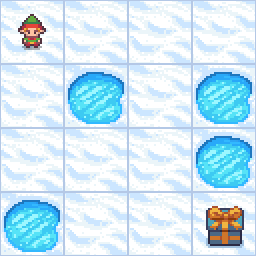

In [ ]:
from IPython.display import Image
Image('./replay_sarsa.gif')